# 05 – RQ3: restoring blurred and noisy drone footage
In this notebook, we degrade aerial frames with known blur and noise and then
restore them. We compare frequency-domain methods (the inverse filter,
the Wiener filter and Richardson-Lucy deconvolution) against spatial
filters. We measure what restoration recovers: pixel quality, but also detection
accuracy.

- Part A: we compute PSNR, SSIM and runtime for every method.
- Part B: we sweep the K parameter of the Wiener filter.
- Part C: we measure detection AP50 on clean, degraded and restored frames
  over the full VisDrone validation split.
- Part D (optional): we test on real blur from the GoPro dataset.


In [1]:
# Local execution (no Colab): put src on the path; write outputs to a
# scratch folder so the committed results are left untouched.
%matplotlib inline
import sys
from pathlib import Path
PROJ = Path(r'/Users/natalikobrii/Documents/STUDY YORKU & UofT/Computer Vision/Project')
sys.path.insert(0, str(PROJ / 'src')); sys.path.insert(0, str(PROJ))
import torch
print('MPS available:', torch.backends.mps.is_available())
OUT = Path(r'/private/tmp/claude-501/-Users-natalikobrii-Documents-STUDY-YORKU---UofT-Computer-Vision/1ed68044-1713-474c-9d99-5f05afa3a715/scratchpad/nb_out'); OUT.mkdir(parents=True, exist_ok=True)

MPS available: True


In [2]:
# The VisDrone-person validation set is already prepared locally.
import config
config.VISDRONE_PERSON = PROJ / 'data' / 'visdrone_person'
n_img = len(list((config.VISDRONE_PERSON/'images'/'val').glob('*.jpg')))
n_lbl = len(list((config.VISDRONE_PERSON/'labels'/'val').glob('*.txt')))
print(f'val: {n_img} images, {n_lbl} label files -> {config.VISDRONE_PERSON}')

val: 548 images, 548 label files -> /Users/natalikobrii/Documents/STUDY YORKU & UofT/Computer Vision/Project/data/visdrone_person


In [3]:
# Part A: measure PSNR, SSIM and runtime over 200 frames.
import cv2, eval_restore, eval_detect
eval_restore.VISDRONE_PERSON = config.VISDRONE_PERSON
eval_detect.VISDRONE_PERSON = config.VISDRONE_PERSON
imgs = []
for p in sorted((config.VISDRONE_PERSON/'images'/'val').glob('*.jpg'))[:200]:
    im = cv2.imread(str(p))
    if im is None: continue
    s = min(1.0, 1280/im.shape[1])
    imgs.append(cv2.resize(im, None, fx=s, fy=s) if s < 1 else im)
rows = eval_restore.run_intrinsic(imgs, out_csv=OUT/'restoration_intrinsic_full.csv')

{'condition': 'motion15_n2', 'method': 'none', 'PSNR': 23.79, 'SSIM': 0.6306, 'ms': 0.0, 'n_images': 200}
{'condition': 'motion15_n2', 'method': 'inverse', 'PSNR': 8.36, 'SSIM': 0.067, 'ms': 92.6, 'n_images': 200}
{'condition': 'motion15_n2', 'method': 'wiener', 'PSNR': 25.89, 'SSIM': 0.6787, 'ms': 80.9, 'n_images': 200}
{'condition': 'motion15_n2', 'method': 'rl20', 'PSNR': 26.71, 'SSIM': 0.7563, 'ms': 2681.9, 'n_images': 200}
{'condition': 'motion15_n2', 'method': 'unsharp', 'PSNR': 23.28, 'SSIM': 0.589, 'ms': 1.9, 'n_images': 200}
{'condition': 'motion15_n2', 'method': 'gaussian', 'PSNR': 23.82, 'SSIM': 0.631, 'ms': 0.9, 'n_images': 200}
{'condition': 'motion25_n5', 'method': 'none', 'PSNR': 22.52, 'SSIM': 0.5518, 'ms': 0.0, 'n_images': 200}
{'condition': 'motion25_n5', 'method': 'inverse', 'PSNR': 6.06, 'SSIM': 0.0225, 'ms': 92.3, 'n_images': 200}
{'condition': 'motion25_n5', 'method': 'wiener', 'PSNR': 23.46, 'SSIM': 0.5911, 'ms': 77.7, 'n_images': 200}
{'condition': 'motion25_n5'

Best K: 0.046415888336127774


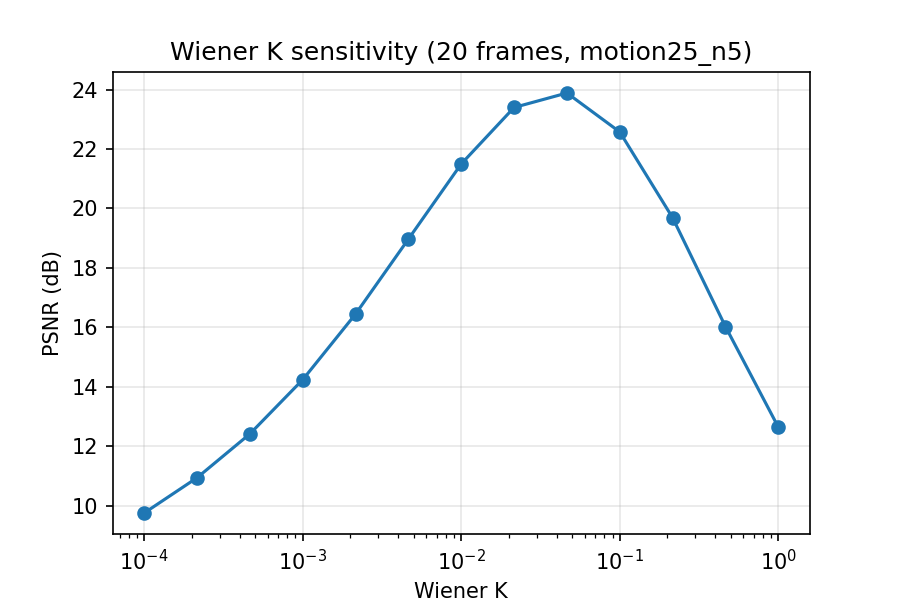

In [4]:
# Part B: run the Wiener K sweep, averaged over 20 frames.
import numpy as np, matplotlib.pyplot as plt
from restore import wiener_filter
from eval_restore import conditions, degrade_by, psnr
cond = next(c for c in conditions() if c['name']=='motion25_n5')
Ks = np.logspace(-4, 0, 13)
curves = []
for img in imgs[:20]:
    deg = degrade_by(cond, img, seed=0)
    curves.append([psnr(wiener_filter(deg, cond['psf'], K), img) for K in Ks])
mean = np.mean(curves, 0)
plt.figure(figsize=(6,4)); plt.semilogx(Ks, mean, marker='o')
plt.xlabel('Wiener K'); plt.ylabel('PSNR (dB)'); plt.grid(alpha=.3)
plt.title('Wiener K sensitivity (20 frames, motion25_n5)')
plt.savefig(OUT/'restoration_wiener_k_full.png', dpi=150)
print('Best K:', float(Ks[int(np.argmax(mean))]))

In [5]:
# Part C: measure detection AP50 on clean, degraded and restored frames,
# using the fine-tuned detector from notebook 01.
det_w = str(PROJ / 'models' / 'yolo11s_visdrone_best.pt')
print('Using fine-tuned detector:', det_w)
from eval_restore import conditions, detection_under_degradation, write_csv
conds = {c['name']: c for c in conditions()}
rows  = detection_under_degradation(det_w, conds['motion25_n5'],
        ['wiener','rl20','unsharp'], max_images=548, device='mps')
rows += detection_under_degradation(det_w, conds['noise25'],
        ['median','nlm','butterworth'], max_images=548, device='mps')
write_csv(rows, OUT/'restoration_extrinsic_detection_full.csv')

Using fine-tuned detector: /Users/natalikobrii/Documents/STUDY YORKU & UofT/Computer Vision/Project/models/yolo11s_visdrone_best.pt
  20/548 images
  40/548 images
  60/548 images
  80/548 images
  100/548 images
  120/548 images
  140/548 images
  160/548 images
  180/548 images
  200/548 images
  220/548 images
  240/548 images
  260/548 images
  280/548 images
  300/548 images
  320/548 images
  340/548 images
  360/548 images
  380/548 images
  400/548 images
  420/548 images
  440/548 images
  460/548 images
  480/548 images
  500/548 images
  520/548 images
  540/548 images
{'condition': 'motion25_n5', 'variant': 'clean', 'AP50': 0.7086, 'recall': 0.8586, 'n_pred': 62955, 'n_images': 548}
{'condition': 'motion25_n5', 'variant': 'degraded', 'AP50': 0.0254, 'recall': 0.0672, 'n_pred': 11316, 'n_images': 548}
{'condition': 'motion25_n5', 'variant': 'wiener', 'AP50': 0.091, 'recall': 0.141, 'n_pred': 8012, 'n_images': 548}
{'condition': 'motion25_n5', 'variant': 'rl20', 'AP50': 0.078

In [6]:
# Part D (optional): real-blur test on the GoPro dataset (about 9.5 GB).
# Off by default; the synthetic study above is the RQ3 result.
RUN_PART_D = False
if not RUN_PART_D:
    print('Part D skipped (optional GoPro real-blur test).')

Part D skipped (optional GoPro real-blur test).


Together, the three parts answer the RQ3 question: whether restoration
recovers detection accuracy, or only pixel quality.
